## Bài 1:

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
brain_ct = cv2.imread('/content/BrainCT.png', cv2.IMREAD_GRAYSCALE)
if brain_ct is None:
    print("Error: Could not load the image.")
    exit()

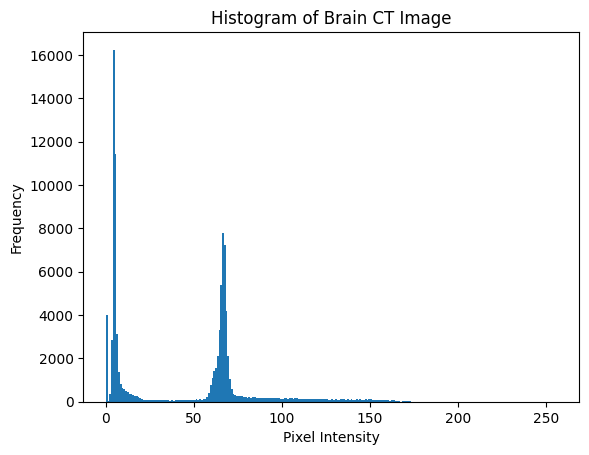

In [ ]:
plt.hist(brain_ct.ravel(), bins=256, range=[0, 256])
plt.title("Histogram of Brain CT Image")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

In [ ]:
thresholds = [50,80,90,110, 130]

kernel_open = np.ones((2, 2), np.uint8)  # 2x2 kernel for opening
kernel_close = np.ones((3, 3), np.uint8)  # 3x3 kernel for closing
kernel_dilate = np.ones((2, 2), np.uint8)  # 2x2 kernel for dilation
kernel_erode = np.ones((2, 2), np.uint8)  # 2x2 kernel for erosion



Processing with Threshold T = 50


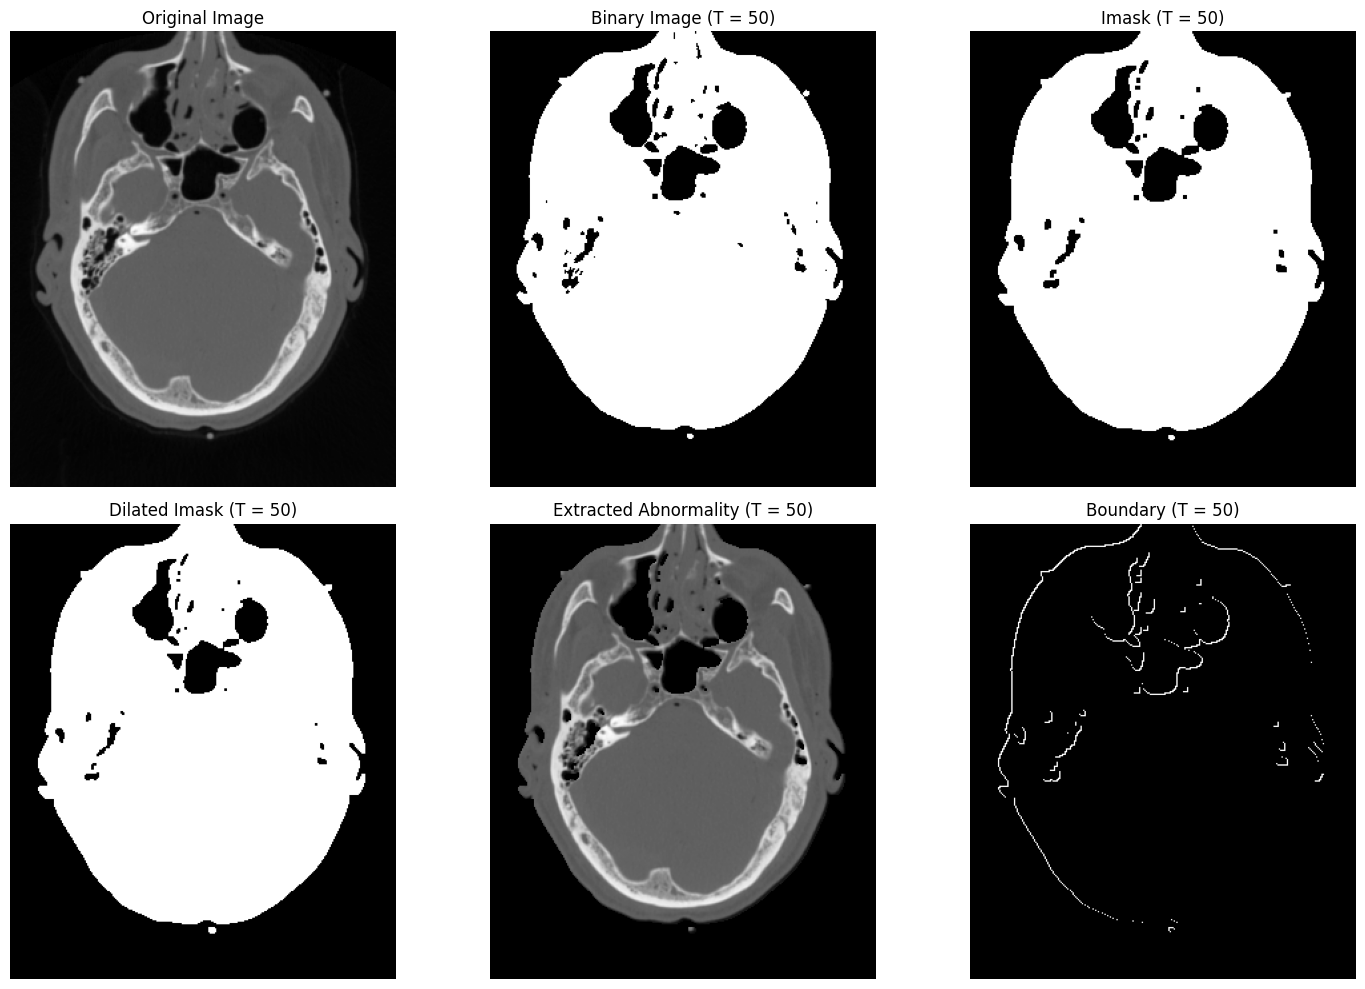


Processing with Threshold T = 80


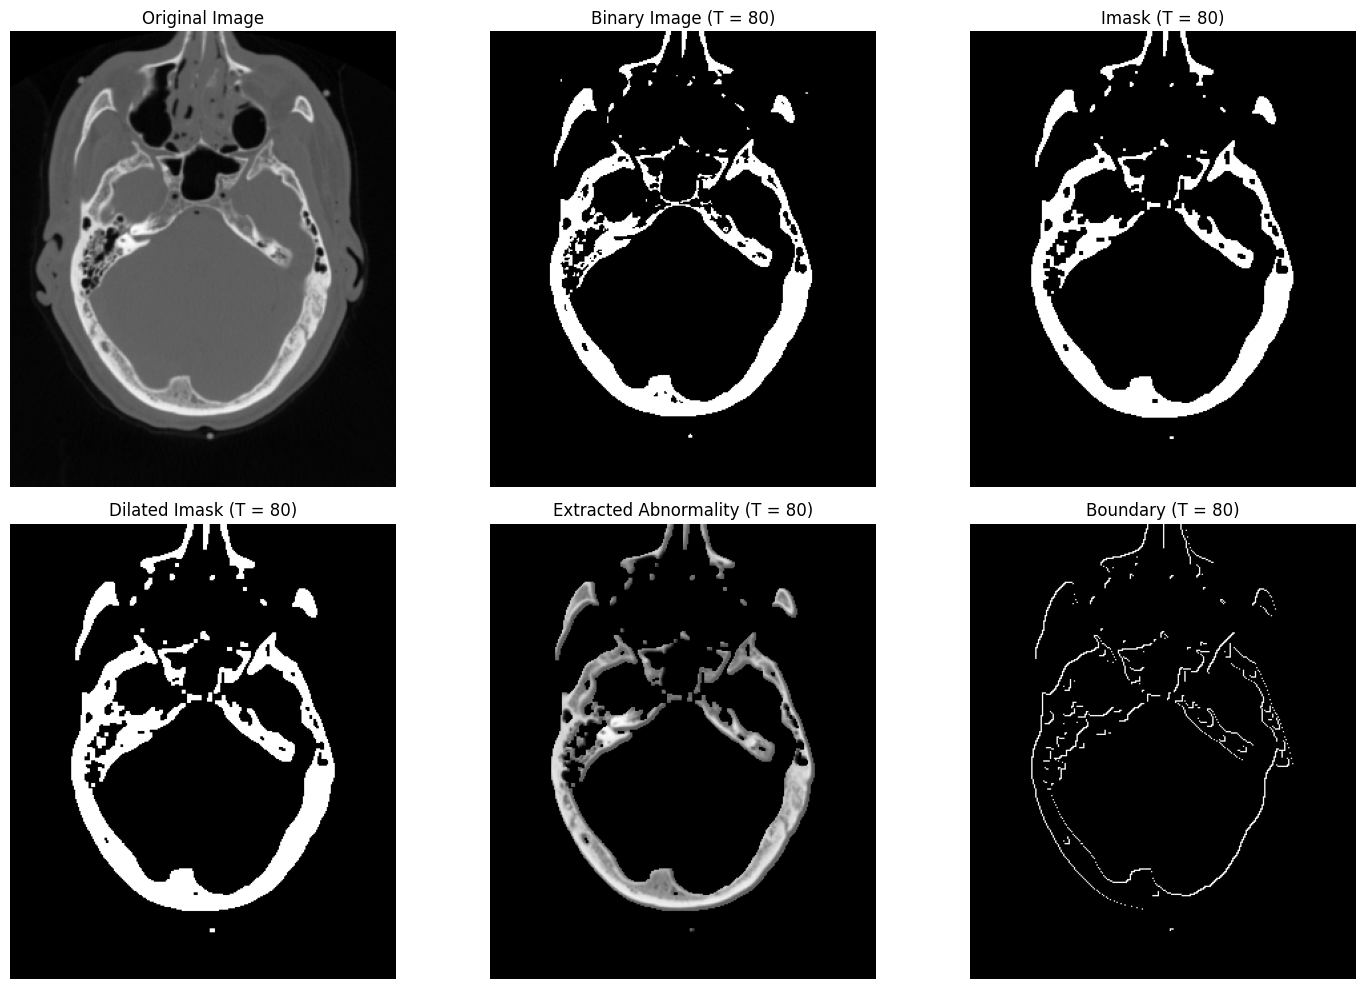


Processing with Threshold T = 90


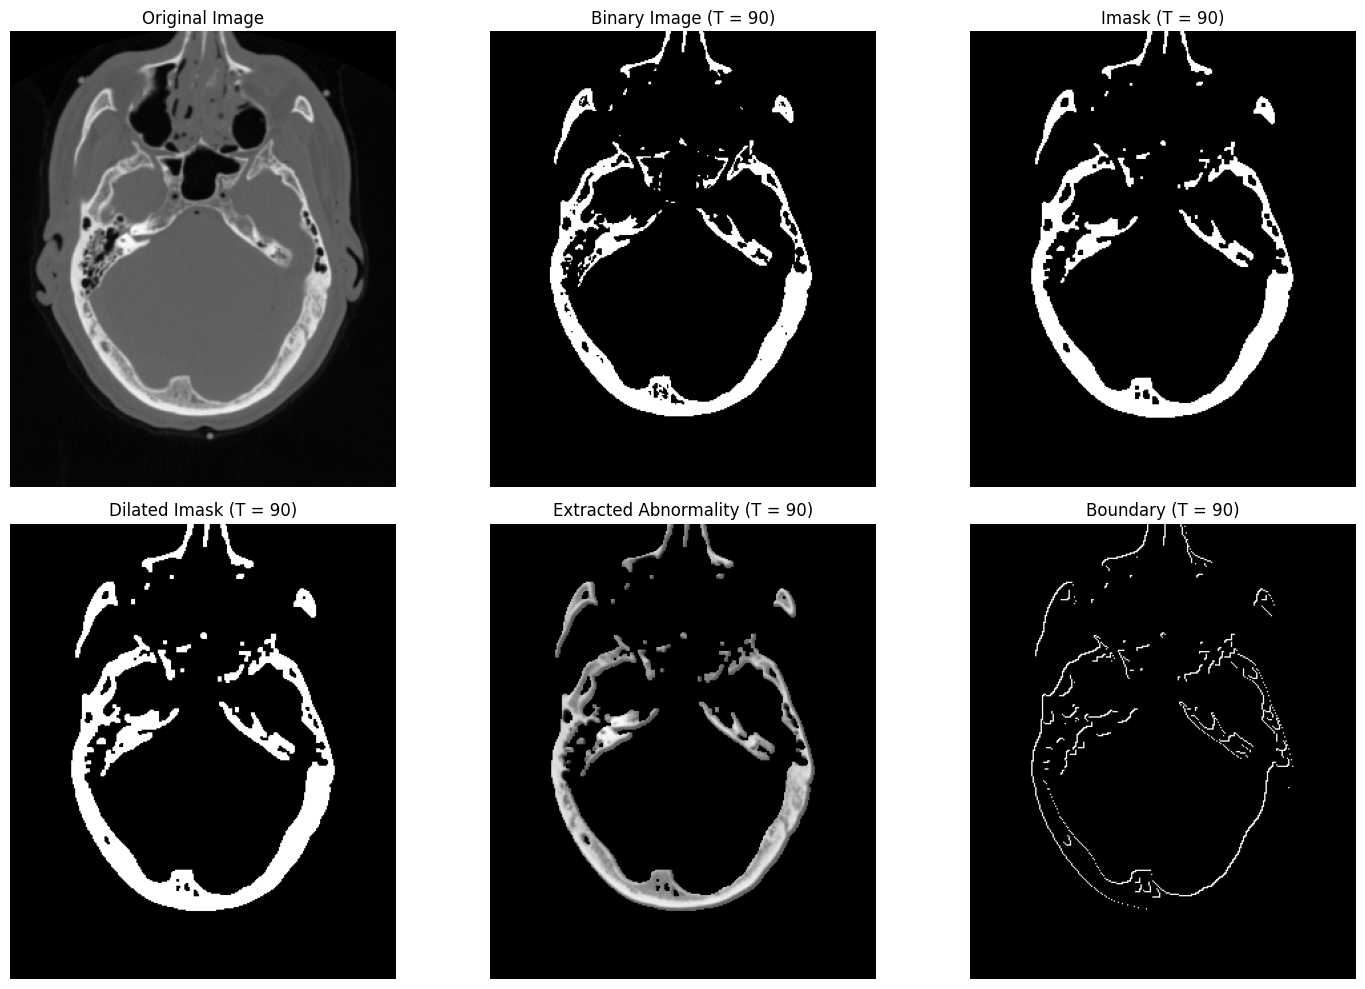


Processing with Threshold T = 110


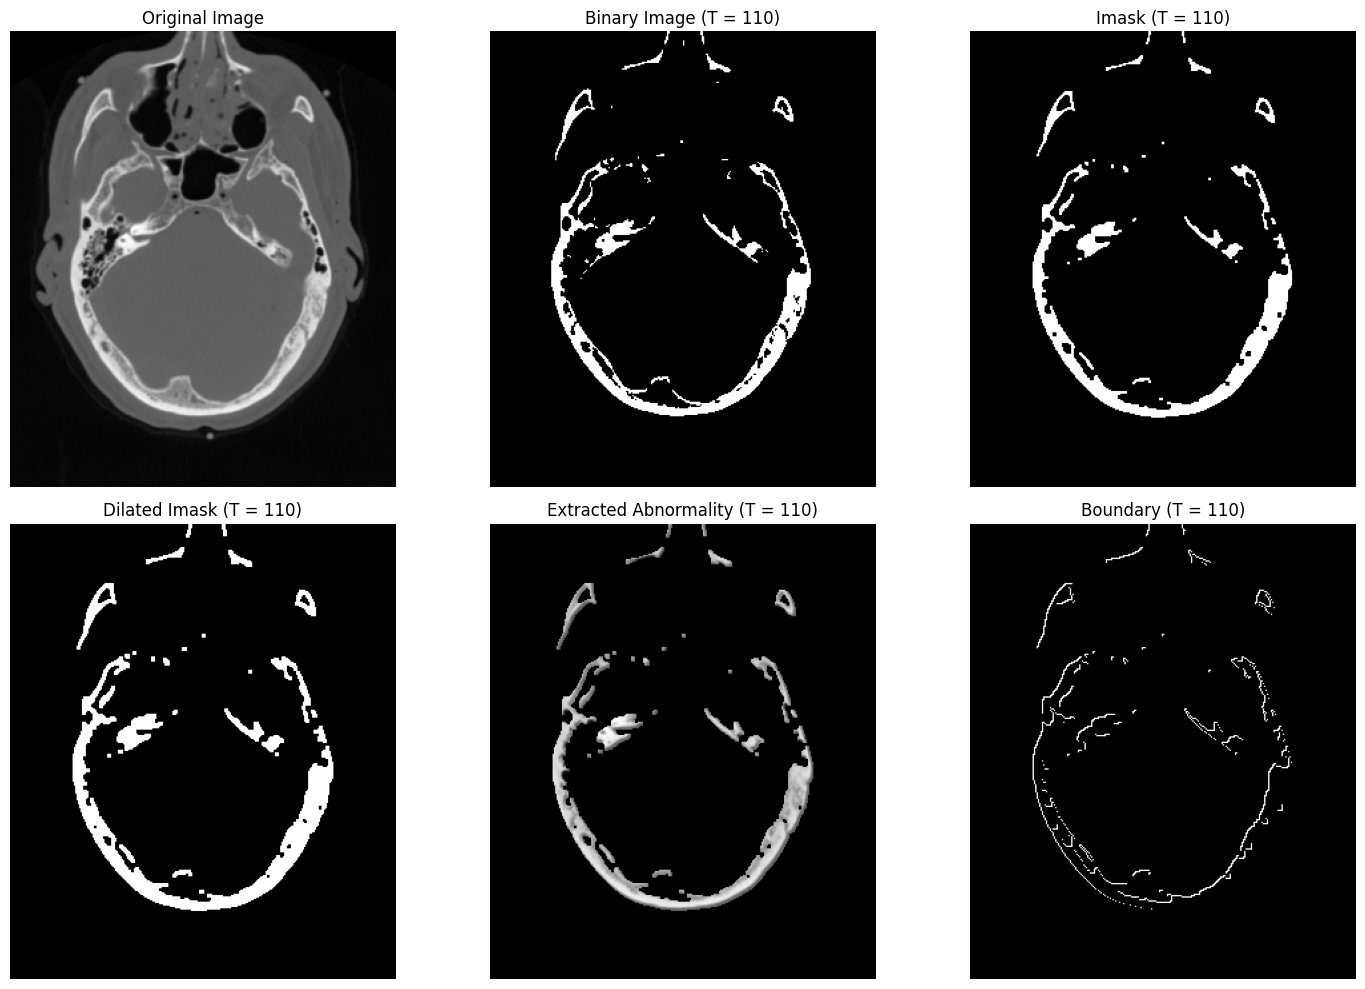


Processing with Threshold T = 130


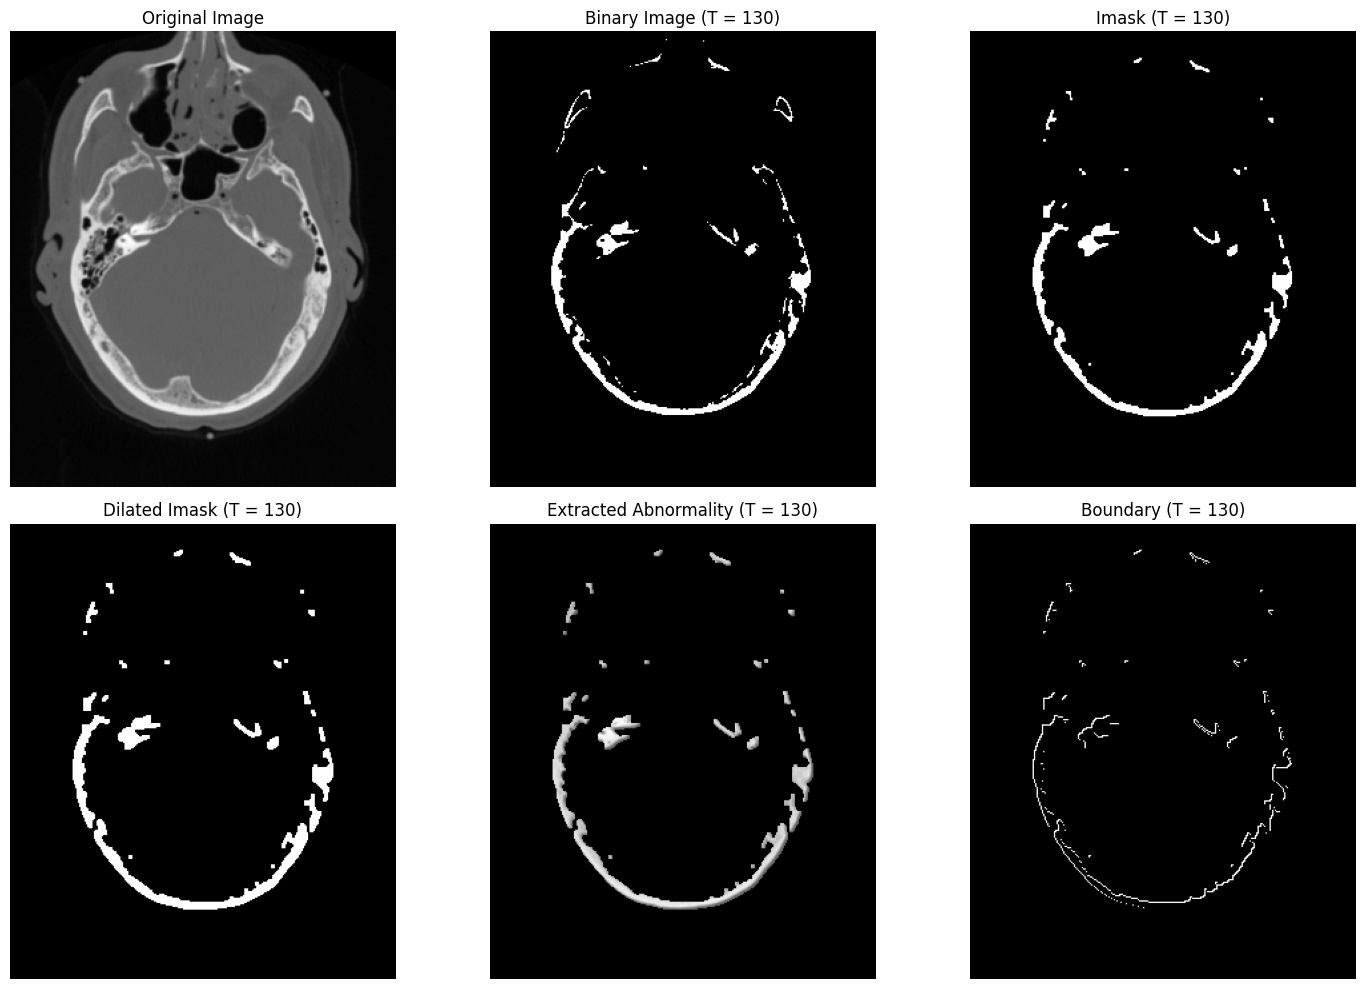

In [ ]:
for T in thresholds:
    print(f"\nProcessing with Threshold T = {T}")

    _, binary_image = cv2.threshold(brain_ct, T, 255, cv2.THRESH_BINARY)
    opened_image = cv2.morphologyEx(binary_image, cv2.MORPH_OPEN, kernel_open)
    closed_image = cv2.morphologyEx(opened_image, cv2.MORPH_CLOSE, kernel_close)

    Imask = closed_image
    dilated_Imask = cv2.dilate(Imask, kernel_dilate, iterations=1)
    extracted_abnormality = cv2.bitwise_and(brain_ct, brain_ct, mask=dilated_Imask)
    eroded_Imask = cv2.erode(Imask, kernel_erode, iterations=1)
    boundary = cv2.subtract(Imask, eroded_Imask)

    plt.figure(figsize=(15, 10))

    plt.subplot(2, 3, 1)
    plt.title(f"Original Image")
    plt.imshow(brain_ct, cmap='gray')
    plt.axis('off')

    plt.subplot(2, 3, 2)
    plt.title(f"Binary Image (T = {T})")
    plt.imshow(binary_image, cmap='gray')
    plt.axis('off')

    plt.subplot(2, 3, 3)
    plt.title(f"Imask (T = {T})")
    plt.imshow(Imask, cmap='gray')
    plt.axis('off')

    plt.subplot(2, 3, 4)
    plt.title(f"Dilated Imask (T = {T})")
    plt.imshow(dilated_Imask, cmap='gray')
    plt.axis('off')

    plt.subplot(2, 3, 5)
    plt.title(f"Extracted Abnormality (T = {T})")
    plt.imshow(extracted_abnormality, cmap='gray')
    plt.axis('off')

    plt.subplot(2, 3, 6)
    plt.title(f"Boundary (T = {T})")
    plt.imshow(boundary, cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    # Save the results for the current threshold (optional)
    cv2.imwrite(f'Imask_T_{T}.png', Imask)
    cv2.imwrite(f'extracted_abnormality_T_{T}.png', extracted_abnormality)
    cv2.imwrite(f'boundary_T_{T}.png', boundary)

## Bài 2

In [ ]:
image2 = cv2.imread('/content/images2.jpg', cv2.IMREAD_GRAYSCALE)
if image2 is None:
    print("Error: Could not load the image.")
    exit()

In [ ]:
image_resized = cv2.resize(image2, (224, 224))

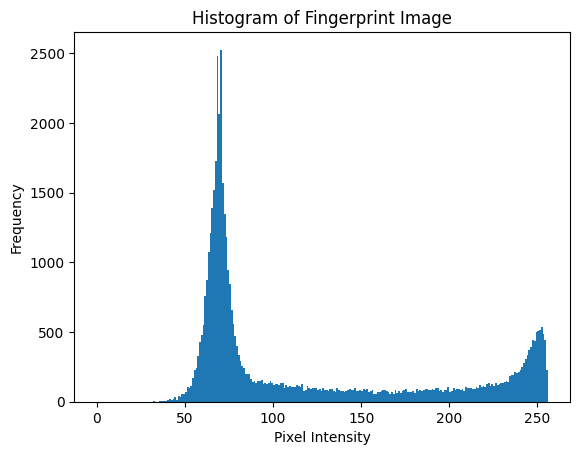

In [ ]:
plt.hist(image_resized.ravel(), bins=256, range=[0, 256])
plt.title("Histogram of Fingerprint Image")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

In [ ]:
T = 128
_, binary_image = cv2.threshold(image_resized, T, 255, cv2.THRESH_BINARY_INV)
A = binary_image

In [ ]:
B = np.ones((3, 3), np.uint8)
opened_image = cv2.morphologyEx(A, cv2.MORPH_OPEN, B)

# Perform closing on the opened image ((A ∘ B) • B) = [(A ∘ B) ⊖ B] ⊕ B
closed_image = cv2.morphologyEx(opened_image, cv2.MORPH_CLOSE, B)
denoised_morph = closed_image
median_filtered = cv2.medianBlur(image_resized, 3)
_, median_binary = cv2.threshold(median_filtered, T, 255, cv2.THRESH_BINARY_INV)

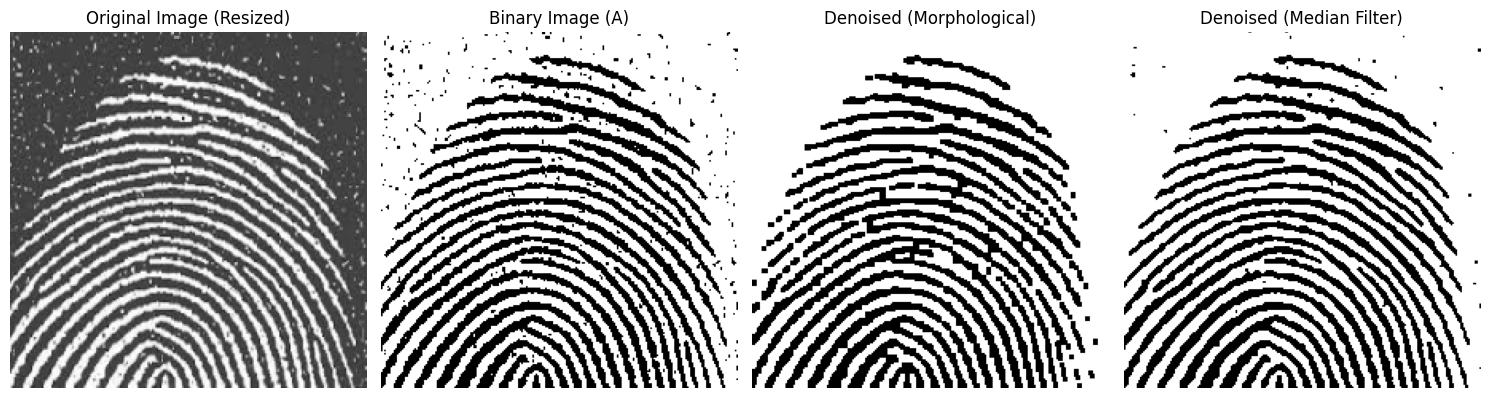

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.title("Original Image (Resized)")
plt.imshow(image_resized, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.title("Binary Image (A)")
plt.imshow(A, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.title("Denoised (Morphological)")
plt.imshow(denoised_morph, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.title("Denoised (Median Filter)")
plt.imshow(median_binary, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
cv2.imwrite('denoised_morphological.png', denoised_morph)
cv2.imwrite('denoised_median.png', median_binary)

print("Evaluation:")
print("- Morphological Denoising: The opening operation removes small white noise, and the closing operation fills small gaps, preserving the fingerprint ridges.")
print("- Median Filter: Smooths the image but may blur the ridges, potentially losing fine details.")
print("Conclusion: Morphological denoising is likely better for fingerprint images as it preserves ridge structure while removing noise.")

Evaluation:
- Morphological Denoising: The opening operation removes small white noise, and the closing operation fills small gaps, preserving the fingerprint ridges.
- Median Filter: Smooths the image but may blur the ridges, potentially losing fine details.
Conclusion: Morphological denoising is likely better for fingerprint images as it preserves ridge structure while removing noise.
